# (6주차) 4월17일 

- toc:true
- branch: master
- badges: true
- comments: true
- author: 최규빈

### 강의영상 

### imports 

In [579]:
import numpy as np
import matplotlib.pyplot as plt 

In [580]:
import tensorflow as tf 

In [581]:
import tensorflow.experimental.numpy as tnp 

In [582]:
tnp.experimental_enable_numpy_behavior()

In [583]:
import graphviz
def gv(s): return graphviz.Source('digraph G{ rankdir="LR"'+s + '; }')

### piece-wise linear regression

model: $y_i= \begin{cases} -x_i +0.3\epsilon_i & x\leq 0  \\ 3.5 x_i +0.3\epsilon_i & x>0 \end{cases}$

In [584]:
np.random.seed(43052)
N=100
x = np.linspace(-1,1,N)
lamb = lambda x: x*1+np.random.normal()*0.3 if x<0 else x*3.5 +np.random.normal()*0.3 
y = np.array(list(map(lamb,x)))

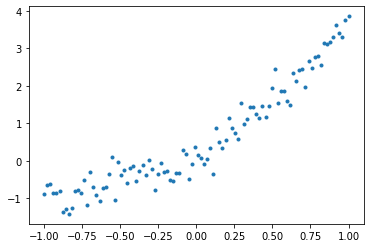

In [585]:
plt.plot(x,y,'.')

#### 풀이1: 단순회귀모형

In [701]:
x= x.reshape(N,1)
y= y.reshape(N,1)

In [702]:
net = tf.keras.Sequential() 
net.add(tf.keras.layers.Dense(1)) 
net.compile(optimizer=tf.optimizers.SGD(0.1),loss='mse')
net.fit(x,y,batch_size=N,epochs=1000,verbose=0) # numpy로 해도 잘 돌아감

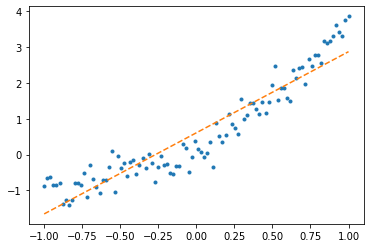

In [703]:
yhat = net.predict(x) ## 이것도 가능
plt.plot(x,y,'.')
plt.plot(x,yhat,'--')

`-` 실패: 그리고 epoch을 10억번 반복해도 이건 실패할 모형임
- 왜? 아키텍처 설계자체가 틀림
- 꺽인부분을 표현하기에는 아키텍처의 표현력이 너무나 부족함 $\to$ under fit의 문제 

#### 풀이2: 비선형 활성화 함수를 도입 

`-` 네트워크를 아래와 같이 수정하자. (hat은 생략하겠음) 

(수정전) 

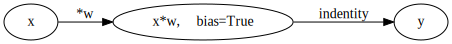

In [704]:
#collapse
gv('''
"x" -> "x*w,    bias=True"[label="*w"] ;
"x*w,    bias=True" -> "y"[label="indentity"] ''')


(수정후) 

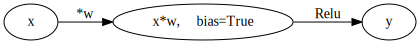

In [705]:
#collapse
gv('''
"x" -> "x*w,    bias=True"[label="*w"] ;
"x*w,    bias=True" -> "y"[label="Relu"] ''')


`-` activation 개념 도입

In [706]:
_x = np.linspace(-1,1,100)
tf.nn.relu(_x)

<tf.Tensor: shape=(100,), dtype=float64, numpy=
array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.01010101, 0.03030303, 0.05050505, 0.07070707, 0.09090909,
       0.11111111, 0.13131313, 0.15151515, 0.17171717, 0.19191919,
       0.21212121, 0.23232323, 0.25252525, 0.27272727, 0.29292929,
       0.31313131, 0.33333333, 0.35353535, 0.37373737, 0.39393939,
       0.41414

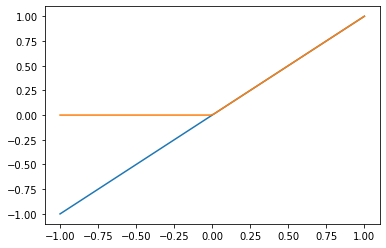

In [707]:
plt.plot(_x,_x) 
plt.plot(_x,tf.nn.relu(_x))

- $f(x)= \max(0,x)= \begin{cases} 0 & x\leq 0  \\ x & x>0 \end{cases}$

`-` 풀이시작 

**1단계**

In [708]:
net2 = tf.keras.Sequential() 

**2단계**

In [727]:
tf.random.set_seed(43053)
l1 = tf.keras.layers.Dense(1, input_shape=(1,)) 
a1 = tf.keras.layers.Activation(tf.nn.relu)

In [728]:
net2.add(l1) 

In [729]:
net2.layers

In [730]:
net2.add(a1) 

In [731]:
net2.layers

In [732]:
l1.get_weights(), net2.get_weights()

([array([[0.41721308]], dtype=float32), array([0.], dtype=float32)],
 [array([[3.7070906]], dtype=float32),
  array([-0.14449845], dtype=float32),
  array([[0.41721308]], dtype=float32),
  array([0.], dtype=float32)])

(네트워크 상황 확인)

In [733]:
u1 = x@l1.weights[0] + l1.weights[1] # 그럴것 같아서? 
u1 = l1(x) # 우연히 알게되었음

In [734]:
v1 = tf.nn.relu(u1)
v1 = a1(u1)

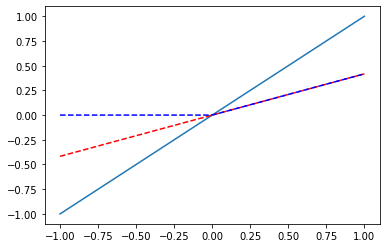

In [735]:
plt.plot(x,x)
plt.plot(x,u1,'--r')
plt.plot(x,v1,'--b')

**3단계**

In [736]:
net2.compile(optimizer=tf.optimizers.SGD(0.1), loss='mse')

**4단계**

In [737]:
net2.fit(x,y,epochs=1000,verbose=0,batch_size=N)

`-` result

In [738]:
yhat= tf.nn.relu(x@net2.weights[0]+net2.weights[1])
yhat= net2.predict(x)
yhat= net2(x)
yhat= a1(l1(x))
yhat= net2.layers[1](net2.layers[0](x))

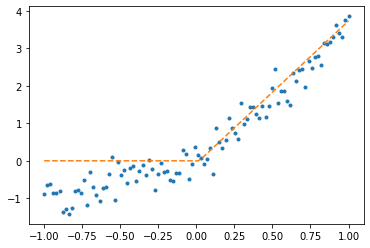

In [739]:
plt.plot(x,y,'.')
plt.plot(x,yhat,'--')

`-` discussion 
- 이것 역시 수백억번 epoc을 반복해도 이 이상 적합하기 힘들다 $\to$ 모형의 표현력이 떨어진다. 
- 해결책: 주황색점선이 2개 있다면 어떨까? 

#### 풀이3: 노드수추가 + 레이어추가 

목표: 2개의 주황색 점선을 만들자. 

**1단계**

In [740]:
net3 = tf.keras.Sequential()

**2단계**

In [741]:
tf.random.set_seed(43053)
l1 = tf.keras.layers.Dense(2, input_shape=(1,)) 
a1 = tf.keras.layers.Activation(tf.nn.relu)

In [742]:
net3.add(l1)
net3.add(a1)

(네트워크상황 확인)

In [743]:
l1(x).shape
# l1(x) # (100,1) -> (100,2) 

TensorShape([100, 2])

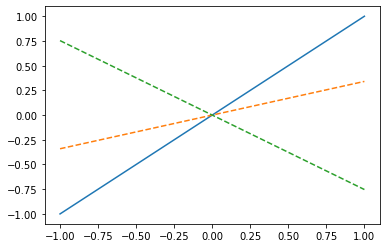

In [744]:
plt.plot(x,x)
plt.plot(x,l1(x),'--')

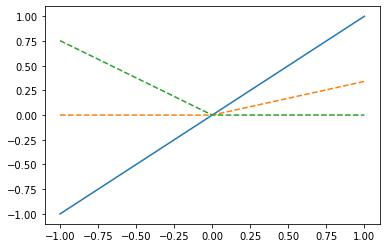

In [745]:
plt.plot(x,x)
plt.plot(x,a1(l1(x)),'--')

`-` 생각해보니까 이대로는 yhat이 안나온다. 왜? 
- 차원이 안맞음. `a1(l1(x))`의 차원은 (N,2)인데 최종적인 yhat의 차원은 (N,1)이어야함 
- 차원이 어찌저찌 맞는다쳐도 relu를 통과하면 항상 $yhat>0$임. 따라서 음수값을 가지는 y는 0으로 밖에 맞출수 없음. 

`-` 해결책: a1(l1(x))의 출력에 연속으로 (Sequential하게!!) 또 다른 레이어를 설계! 
- `yhat = bias + weight1 * a1(l1(x))[0] + weight2 * a1(l1(X))[1]`

`-` 써보니까 그냥 선형모형 $\to$ al(l1(x))를 그냥 새로운 입력으로 해석하고 선형모형을 태우면 된다. 
- 입력차원: 2 
- 출력차원: 1 

In [746]:
net3.layers

In [747]:
tf.random.set_seed(43053)
l2 = tf.keras.layers.Dense(1,input_shape=(2,))

In [748]:
net3.add(l2)

In [749]:
net3.layers

In [750]:
net3.summary()

Model: "sequential_212"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_512 (Dense)           (None, 2)                 4         
                                                                 
 activation_8 (Activation)   (None, 2)                 0         
                                                                 
 dense_513 (Dense)           (None, 1)                 3         
                                                                 
Total params: 7
Trainable params: 7
Non-trainable params: 0
_________________________________________________________________


`-` 오.. 이런느낌! (추정할 파라메터 수를 좀 따져볼까?) 

`-` 수식표현: $X \to X @ W^{(1)} \to relu(X@W^{(1)}+b^{(1)}) \to relu(X@W^{(1)}+b^{(1)})@ W^{(2)}+b^{(2)} = yhat$
- $X$: (n,1)
- $W^{(1)}$: (1,2) ==> 파라메터 2개 
- $b^{(1)}$: (2,1) ==> 여기서 파라메터 2개 추가  // 1층에서는 파라매터 4개 
- $W^{(2)}$: (2,1) ==> 파라메터 2개
- $b^{(2)}$: (1,1) ==> 파라메터 1개추가 // 2층에서는 파라메터 3개 

`-` 참고: **추정할 파라메터 수가 많다 = 복잡한 모형이다** 
- 초거대AI: 추정할 파라메터수가 엄청 많은.. 

In [751]:
net3.weights

[<tf.Variable 'dense_512/kernel:0' shape=(1, 2) dtype=float32, numpy=array([[ 0.34065306, -0.7533803 ]], dtype=float32)>,
 <tf.Variable 'dense_512/bias:0' shape=(2,) dtype=float32, numpy=array([0., 0.], dtype=float32)>,
 <tf.Variable 'dense_513/kernel:0' shape=(2, 1) dtype=float32, numpy=
 array([[ 0.34065306],
        [-0.7533803 ]], dtype=float32)>,
 <tf.Variable 'dense_513/bias:0' shape=(1,) dtype=float32, numpy=array([0.], dtype=float32)>]

In [752]:
l1.weights

[<tf.Variable 'dense_512/kernel:0' shape=(1, 2) dtype=float32, numpy=array([[ 0.34065306, -0.7533803 ]], dtype=float32)>,
 <tf.Variable 'dense_512/bias:0' shape=(2,) dtype=float32, numpy=array([0., 0.], dtype=float32)>]

In [753]:
l2.weights

[<tf.Variable 'dense_513/kernel:0' shape=(2, 1) dtype=float32, numpy=
 array([[ 0.34065306],
        [-0.7533803 ]], dtype=float32)>,
 <tf.Variable 'dense_513/bias:0' shape=(1,) dtype=float32, numpy=array([0.], dtype=float32)>]

`-` 좀 더 간단한 수식표현: $ X \to (u_1 \to v_1) \to (u_2 \to v_2):=yhat$
- $u_1= X@W^{(1)}+b^{(1)}$
- $v_1= relu(u_1)$
- $u_2= v_1 @ W^{(2)}+b^{(2)}$
- $v_2= identity(u_2) := yhat$

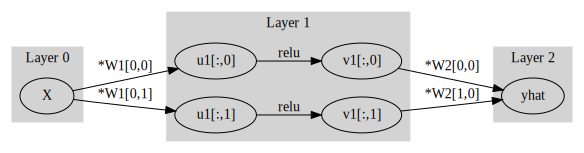

In [754]:
#collapse
gv('''
subgraph cluster_1{
    style=filled;
    color=lightgrey;
    "X" 
    label = "Layer 0"
}
subgraph cluster_2{
    style=filled;
    color=lightgrey;
    "X" -> "u1[:,0]"[label="*W1[0,0]"]
    "X" -> "u1[:,1]"[label="*W1[0,1]"]
    "u1[:,0]" -> "v1[:,0]"[label="relu"]
    "u1[:,1]" -> "v1[:,1]"[label="relu"]
    label = "Layer 1"
}
subgraph cluster_3{
    style=filled;
    color=lightgrey;
    "v1[:,0]" -> "yhat"[label="*W2[0,0]"]
    "v1[:,1]" -> "yhat"[label="*W2[1,0]"]
    label = "Layer 2"
}
''')


`-` 좀 더 간단한 다이어그램 

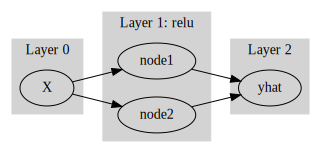

In [755]:
#collapse
gv('''
subgraph cluster_1{
    style=filled;
    color=lightgrey;
    "X" 
    label = "Layer 0"
}
subgraph cluster_2{
    style=filled;
    color=lightgrey;
    "X" -> "node1"
    "X" -> "node2"
    label = "Layer 1: relu"
}
subgraph cluster_3{
    style=filled;
    color=lightgrey;
    "node1" -> "yhat"
    "node2" -> "yhat"
    label = "Layer 2"
}
''')

**3단계**

In [756]:
net3.compile(loss='mse',optimizer=tf.optimizers.SGD(0.1))

**4단계**

In [757]:
net3.fit(x,y,epochs=1000,verbose=0,batch_size=N)

`-` 결과확인 

In [758]:
net3.weights

[<tf.Variable 'dense_512/kernel:0' shape=(1, 2) dtype=float32, numpy=array([[ 1.6352799 , -0.85507524]], dtype=float32)>,
 <tf.Variable 'dense_512/bias:0' shape=(2,) dtype=float32, numpy=array([-0.08284465,  0.85552216], dtype=float32)>,
 <tf.Variable 'dense_513/kernel:0' shape=(2, 1) dtype=float32, numpy=
 array([[ 1.6328746],
        [-1.2001747]], dtype=float32)>,
 <tf.Variable 'dense_513/bias:0' shape=(1,) dtype=float32, numpy=array([1.0253307], dtype=float32)>]

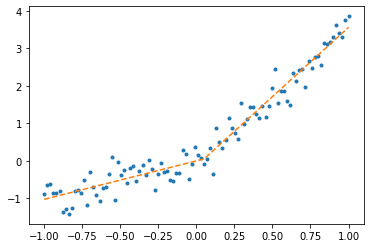

In [759]:
plt.plot(x,y,'.')
plt.plot(x,net3(x),'--')

`-` 분석 

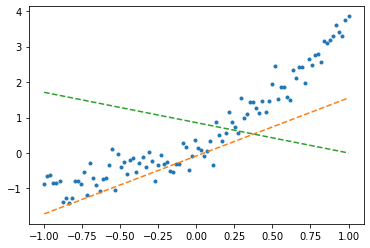

In [760]:
plt.plot(x,y,'.')
plt.plot(x,l1(x),'--')

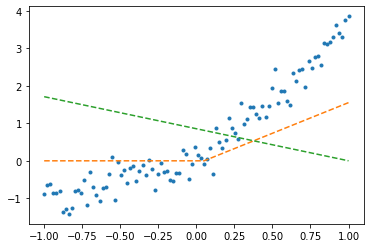

In [761]:
plt.plot(x,y,'.')
plt.plot(x,a1(l1(x)),'--')

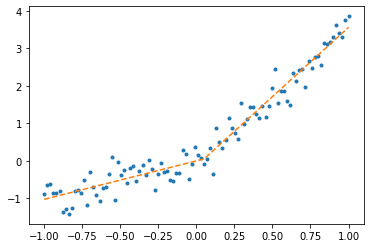

In [762]:
plt.plot(x,y,'.')
plt.plot(x,l2(a1(l1(x))),'--')

`-` 마지막 2개의 그림을 분석 

In [763]:
l2.weights

[<tf.Variable 'dense_513/kernel:0' shape=(2, 1) dtype=float32, numpy=
 array([[ 1.6328746],
        [-1.2001747]], dtype=float32)>,
 <tf.Variable 'dense_513/bias:0' shape=(1,) dtype=float32, numpy=array([1.0253307], dtype=float32)>]

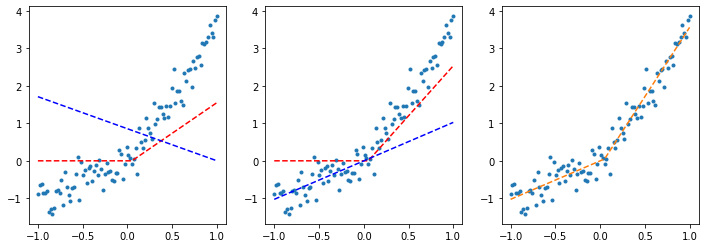

In [765]:
fig, (ax1,ax2,ax3) = plt.subplots(1,3)
fig.set_figwidth(12)
ax1.plot(x,y,'.')
ax1.plot(x,a1(l1(x))[:,0],'--r')
ax1.plot(x,a1(l1(x))[:,1],'--b')
ax2.plot(x,y,'.')
ax2.plot(x,a1(l1(x))[:,0]* 1.6328746,'--r')
ax2.plot(x,a1(l1(x))[:,1]*-1.2001747+1.0253307,'--b')
ax3.plot(x,y,'.')
ax3.plot(x,a1(l1(x))[:,0]*1.6328746+a1(l1(x))[:,1]*-1.2001747+1.0253307,'--')

#### 풀이3의 실패 

In [766]:
tf.random.set_seed(43054)
net3 = tf.keras.Sequential()  
##
net3.add(tf.keras.layers.Dense(2))
net3.add(tf.keras.layers.Activation('relu')) # net3.add(tf.layers.Activation('tf.nn.relu')) 
net3.add(tf.keras.layers.Dense(1))
##
net3.compile(optimizer='sgd',loss='mse')
##
net3.fit(x,y,epochs=1,verbose=0,batch_size=N)
print(net3.weights)
net3.fit(x,y,epochs=999,verbose=0,batch_size=N)

[<tf.Variable 'dense_514/kernel:0' shape=(1, 2) dtype=float32, numpy=array([[-0.06392115,  0.4896328 ]], dtype=float32)>, <tf.Variable 'dense_514/bias:0' shape=(2,) dtype=float32, numpy=array([-0.0035493 , -0.00533678], dtype=float32)>, <tf.Variable 'dense_515/kernel:0' shape=(2, 1) dtype=float32, numpy=
array([[ 0.6534518 ],
       [-0.28900596]], dtype=float32)>, <tf.Variable 'dense_515/bias:0' shape=(1,) dtype=float32, numpy=array([0.0126544], dtype=float32)>]


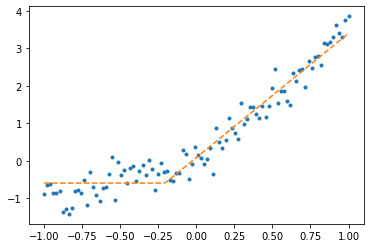

In [767]:
yhat=net3(x)
plt.plot(x,y,'.')
plt.plot(x,yhat,'--')

`-` 엥? 에폭이 부족한가? 

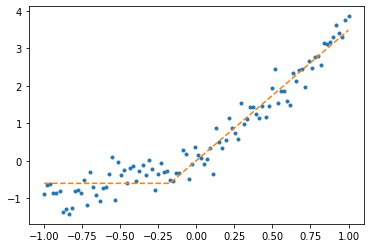

In [768]:
net3.fit(x,y,epochs=10000,verbose=0,batch_size=N)
yhat=net3(x)
plt.plot(x,y,'.')
plt.plot(x,yhat,'--')

`-` 실패분석 

In [769]:
l1,a1,l2 = net3.layers

In [770]:
l2.weights

[<tf.Variable 'dense_515/kernel:0' shape=(2, 1) dtype=float32, numpy=
 array([[0.652382 ],
        [1.8586646]], dtype=float32)>,
 <tf.Variable 'dense_515/bias:0' shape=(1,) dtype=float32, numpy=array([-0.6007662], dtype=float32)>]

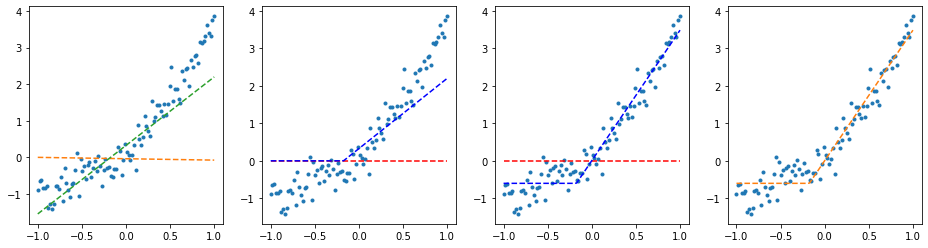

In [771]:
fig, (ax1,ax2,ax3,ax4) = plt.subplots(1,4)
fig.set_figwidth(16)
ax1.plot(x,y,'.')
ax1.plot(x,l1(x),'--')
ax2.plot(x,y,'.')
ax2.plot(x,a1(l1(x))[:,0],'--r')
ax2.plot(x,a1(l1(x))[:,1],'--b')
ax3.plot(x,y,'.')
ax3.plot(x,a1(l1(x))[:,0]*0.652382,'--r')
ax3.plot(x,a1(l1(x))[:,1]*1.8586646+ (-0.6007662),'--b')
ax4.plot(x,y,'.')
ax4.plot(x,a1(l1(x))[:,0]*0.652382+a1(l1(x))[:,1]*1.8586646+(-0.6007662),'--')

- 보니까 첫번째 그림에서 주황색선은 하는일이 없음. 
- 그런데 생각해보니까 이상황에서는 할 수 있는 일이 별로 없음. 
- 왜?? 지금은 나름 파란색에 의해서 최적화가 된 상태임 $\to$ 주황색이 뭔가 하려고하면 파란색에 의한 최적화가 깨지게됨 (loss 증가) 
- 즉 이 상황 자체가 나름의 최적화된 상황이다. 이러한 현상을 "global minimum을 찾지못하고 local minimum에 빠졌다"라고 표현한다. 

확인: 

In [772]:
net3.weights

[<tf.Variable 'dense_514/kernel:0' shape=(1, 2) dtype=float32, numpy=array([[-0.0376876,  1.8719251]], dtype=float32)>,
 <tf.Variable 'dense_514/bias:0' shape=(2,) dtype=float32, numpy=array([-0.03786307,  0.32603154], dtype=float32)>,
 <tf.Variable 'dense_515/kernel:0' shape=(2, 1) dtype=float32, numpy=
 array([[0.652382 ],
        [1.8586646]], dtype=float32)>,
 <tf.Variable 'dense_515/bias:0' shape=(1,) dtype=float32, numpy=array([-0.6007662], dtype=float32)>]

In [773]:
W1 = tf.Variable(tnp.array([[-0.0376876, 1.8719251]]))
b1 = tf.Variable(tnp.array([-0.03786307, 0.32603154]))
W2 = tf.Variable(tnp.array([[0.652382 ],[1.8586646]])) 
b2 = tf.Variable(tnp.array([-0.6007662]))

In [774]:
with tf.GradientTape() as tape: 
    u=tf.constant(x) @ W1 + b1 
    v=tf.nn.relu(u)
    yhat = v @ W2 + b2 
    loss = tf.losses.mse(y,yhat)

In [775]:
tape.gradient(loss,[W1,b1,W2,b2])

[<tf.Tensor: shape=(1, 2), dtype=float64, numpy=array([[ 0.        , -0.00059556]])>,
 <tf.Tensor: shape=(2,), dtype=float64, numpy=array([0.        , 0.00013513])>,
 <tf.Tensor: shape=(2, 1), dtype=float64, numpy=
 array([[ 0.       ],
        [-0.0005761]])>,
 <tf.Tensor: shape=(1,), dtype=float64, numpy=array([-0.00030179])>]

예상대로 계수값이 거의 다 0이다. 

#### 풀이4: 노드수를 더 추가한다면?

`-` 잘 보면 이 문제는 구조상 해가 여러개가 있을 수 있다. 
- $x<0$인 파트를 맞추기 위해서는 (양의 기울기 * 음수의값) $\approx -1$ 의 형태가 항상 필요하다. 이 조합은 무한대임. 

`-` 그래서 이미 over parameter 상태이지만 그래도 좋은 초기값을 가진다면 그럭저럭 잘 맞춘다. 

`-` 여기서 노드수와 레이어를 더 늘리면 어떻게 될까? 

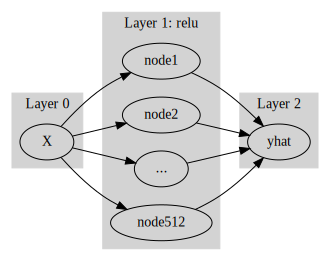

In [814]:
#collapse
gv('''
subgraph cluster_1{
    style=filled;
    color=lightgrey;
    "X" 
    label = "Layer 0"
}
subgraph cluster_2{
    style=filled;
    color=lightgrey;
    "X" -> "node1"
    "X" -> "node2"
    "X" -> "..."
    "X" -> "node512"
    label = "Layer 1: relu"
}
subgraph cluster_3{
    style=filled;
    color=lightgrey;
    "node1" -> "yhat"
    "node2" -> "yhat"
    "..." -> "yhat"
    "node512" -> "yhat"
    label = "Layer 2"
}
''')

In [815]:
tf.random.set_seed(43056)
net4 = tf.keras.Sequential()
net4.add(tf.keras.layers.Dense(512,activation='relu')) # 이렇게해도됩니당
net4.add(tf.keras.layers.Dense(1))
net4.compile(loss='mse',optimizer=tf.optimizers.SGD(0.1))
net4.fit(x,y,epochs=1000,verbose=0,batch_size=N)

In [816]:
net4.optimizer.lr

<tf.Variable 'SGD/learning_rate:0' shape=() dtype=float32, numpy=0.1>

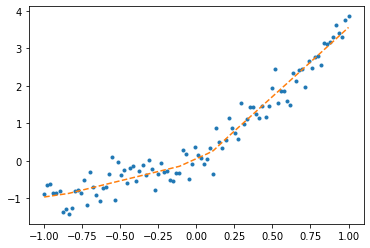

In [817]:
plt.plot(x,y,'.')
plt.plot(x,net4(x),'--')

- 오?!
- 한두개의 노드가 역할을 못해도 다른노드들이 잘 보완해주는듯!

`-` 노드수가 많으면 무조건 좋다? $\to$ 대부분 나쁘지 않음. 그런데 종종 맞추지 말아야할것도 맞춤.. (overfit)

In [818]:
np.random.seed(43052)
N=100
_x = np.linspace(0,1,N).reshape(N,1)
_y = np.random.normal(loc=0,scale=0.001,size=(N,1))

In [819]:
tf.random.set_seed(43052)
net4 = tf.keras.Sequential()
net4.add(tf.keras.layers.Dense(512,activation='relu'))
net4.add(tf.keras.layers.Dense(1))
net4.compile(loss='mse',optimizer=tf.optimizers.SGD(0.5))
net4.fit(_x,_y,epochs=1000,verbose=0,batch_size=N)

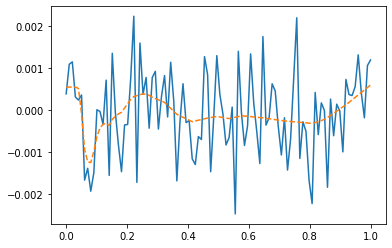

In [820]:
plt.plot(_x,_y)
plt.plot(_x,net4(_x),'--')

- 이 예제는 나중에 또 할거에요 ㅎㅎ 

### Logistic regression

#### Motive 

`-` 현실에서 이런 경우가 많음 
- $x$가 커질수록 (혹은 작아질수록) 성공확률이 증가함

`-` 이러한 모형은 아래와 같이 설계할 수 있음 <-- 외우세요!!
- $y_i \sim Ber(\pi_i)$, where $\pi_i=\frac{\exp(w_0+w_1x_i)}{1+\exp(w_0+w_1x_i)}$
- $\hat{y}_i =\frac{\exp(\hat{w}_0+\hat{w}_1x_i)}{1+\exp(\hat{w}_0+\hat{w}_1x_i)}=\frac{1}{1+exp(-\hat{w}_0-\hat{w}_1x_i)}$
- $loss=-\sum_{i=1}^{n}(y_i\log(\hat{y}_i)+(1-y_i)\log(1-\hat{y}_i)$

In [ ]:
!git add .
!git commit -m .
!git push